Kelin Levine  
March 31, 2026  
COE 311K - Engineering Computation, Spring 2026  
The University of Texas at Austin  
AI was not used in the creation of this report.

# Introduction

This project aims to apply three curve-fitting and interpolation techniques to the U.S. quarterly GDP growth rates from 2010 to 2023. This dataset is sources from the U.S. Bureau of Economic Analysis: Seasonaly adjusted annual rate (SAAR) of real GDP growth, in percent. To analyze it, I will apply least squares linear regression, polynomial fitting via the normal equations, and natural cubic spline interpolation.

# Part A

The following two code cells will initialize the kernel and process/output data, respectively. They must be run in order. Read the cell docstrings for more information, or continue to the discussion below.

In [1]:
"""Initialization Block

This cell initializes in the kernel common library imports, data, and
functions used by other code cells. It must be run before any other
code cells.

This cell should not produce any output by itself.
"""


# Library Imports
import numpy as np
import matplotlib.pyplot as plt


# Dataset: U.S. Quarterly GDP Growth Rate, taken from selected quarters in Dataset
# X axis represents consecutive integer quarter indices.
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56], dtype=float)
# Y axis represents % GDP Growth in the corresponding quarter.
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3], dtype=float)

# This version of the Dataset omits values in the COVID quarters: 2020 Q1 through 2021 Q1
x_nocovid = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 49, 54, 56], dtype=float)
y_nocovid = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3], dtype=float)


def compute_rmse(y, y2) -> float:
    """Compute the Root Mean Squared Error (RMSE) value of a fit.

    y and y2 must be arrays of the same length.
    """
    return np.sqrt(np.mean((y - y2)**2))


def compute_condition(a):
    """Compute the condition number of a matrix."""
    return np.linalg.cond(a)


def report_condition(a):
    """Compute and print the condition number of a matrix."""
    print("Matrix Condition Number:", compute_condition(a))


def report_fit_stats(y, y2, a):
    """Compute and print useful statistics of a fit.

    y and y2 must be arrays of the same length.
    a is the coefficient matrix of the system solved to compute the fit.
    """
    report_condition(a)
    print("Root Mean Squared Error:", compute_rmse(y, y2))


def show_plot(title):
    """Configure and show a plot of GDP growth vs. fiscal quarter."""
    plt.title(title)
    plt.xlabel("Fiscal Quarter (Starting 2010 Q1)")
    plt.ylabel("GDP Growth (%)")
    plt.legend()
    plt.show()


def plot_residuals(title, x, y, y2):
    """Plot, configure, and show a plot of a fit's residuals."""
    r = y - y2
    plt.plot(x, r, 'bo', label="Residuals")
    plt.plot(x, np.zeros(len(x)), 'r--', label="y=0")
    show_plot("Residuals: " + title)


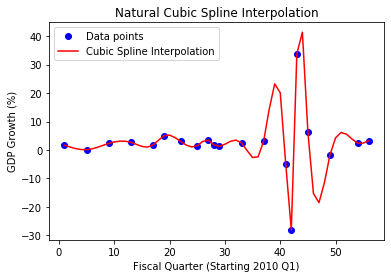

Matrix Condition Number: 6.823490897021205


In [2]:
"""Part A -- Cubic Spline Interpolation

This cell contains functions to construct and evaluate a natural cubic
spline interpolant using a tridiagonal system and the Thomas Algorithm
to compute second derivatives following the second derivative
continuity and natural spline boundary conditions.

When this cell is run, it will calculate and plot a natural cubic
spline interpolation of the Dataset evaluated at every quarter of the
full range. It will also print the condition number of the tridiagonal
matrix used to create the interpolant.

See below for discussion.

This cell must be run AFTER the Initialization Block in the kernel.
"""


def setup_tridiagonal(h, y):
    """Calculate the diagonals and solution vector of a tridiagonal system."""
    n = len(h)
    a = np.zeros(n-1, dtype=float)
    b = np.zeros(n-1, dtype=float)
    c = np.zeros(n-1, dtype=float)
    d = np.zeros(n-1, dtype=float)
    for i in range(1, n):
        a[i-1] = h[i-1]
        b[i-1] = 2.0*(h[i-1]+h[i])
        c[i-1] = h[i]
        d[i-1] = 6.0*(((y[i+1]-y[i]) / h[i]) - ((y[i]-y[i-1]) / h[i-1]))
    return a, b, c, d


def stack_tridiagonal(a, b, c):
    """Stack the diagonals to create the matrix A of a tridiagonal system."""
    subdiag = np.diag(a[1:], -1)
    diag = np.diag(b)
    superdiag = np.diag(c, 1)[:-1,:-1]
    return subdiag + diag + superdiag


def solve_thomas(a, b, c, d):
    """Solve a tridiagonal system for its second derivatives using the Thomas Algorithm."""
    n = len(a)
    for i in range(1, n):
        w = a[i] / b[i-1]
        b[i] -= w * c[i-1]
        d[i] -= w * d[i-1]
    x = np.zeros(n, dtype=float)
    x[n-1] = d[n-1] / b[n-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1]) / b[i]
    return x


def cubic_spline_interp(x, y):
    """Construct and evaluate a natural cubic spline interpolant over integer increments of x."""
    # Step 1: Calculate step sizes
    h = np.diff(x)

    # Step 2: Set up and solve the tridiagonal system
    a, b, c, d = setup_tridiagonal(h, y)
    tri_mat = stack_tridiagonal(a, b, c)
    m = np.array([0.0, *solve_thomas(a, b, c, d), 0.0], dtype=float)

    # Step 3: Evaluate the spline at new points
    # Compile a series of ranges to evaluate
    x2 = [np.arange(x[i], x[i+1]+0.5, dtype=float) for i in range(len(m)-1)]
    y2 = [0]*len(x2)
    # Evaluate the spline for each range of points
    for i, xeval in enumerate(x2):
        th1 = 6.0 * h[i]
        th2 = h[i] / 6.0
        tx1 = x[i+1] - xeval
        tx2 = xeval - x[i]
        y2[i] = ((m[i]/th1)*(tx1**3)
                + (m[i+1]/th1)*(tx2**3)
                + ((y[i]/h[i])-(m[i]*th2))*tx1
                + ((y[i+1]/h[i])-(m[i+1]*th2))*tx2)
    # Trim redundant points
    for i in range(len(x2)-1):
        x2[i] = x2[i][0:-1]
        y2[i] = y2[i][0:-1]
    # Stack ranges
    x2 = np.hstack(x2)
    y2 = np.hstack(y2)
    return x2, y2, tri_mat


# Compute interpolation
x_cs_interp, y_cs_interp, mat_cs_interp = cubic_spline_interp(x, y)

# Plot the results
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_cs_interp, y_cs_interp, 'r-', label="Cubic Spline Interpolation")
show_plot("Natural Cubic Spline Interpolation")
report_condition(mat_cs_interp)


This first part involves constructing a natural cubic spline interpolant through the whole dataset. In cubic spline interpolation, the goal is to interpolate between known points in a dataset by coming up with a piecewise spline function (which can also be thought of as a set of cubic polynomial functions, one for each x-axis interval between data points) that smoothly passes through every known point in the dataset. To ensure that the function fits the dataset in a way that is smooth and natural, it must satisfy the smoothness condition, which imposes at least three requirements: the interpolation condition, which requires the spline to pass through each data point; continuity of first derivatives, which requires the first derivative of the spline to be continuous at each data point (where the cubic polynomial changes); continuity of second derivatives, which requires the second derivative of the spline to also be continuous at each data point. Additionally, the spline function must also have a boundary condition that determines the second derivatives at the endpoints. For a natural spline, the second derivatives at the endpoints are always 0. Using the smoothness condition, we can derive an equation that relates each interval of data points (excluding the endpoints) to the second derivative of the cubic spline that smoothly connects the data points. Then, by applying this equation to each interval, the cubic spline interpolant can be represented and solved as a tridiagonal system of equations in matrix form. For a dataset of n data points, the tridiagonal system for natural cubic splines has a size of n-2 by n-2. Solving this system of equations can be done easily using the Thomas Algorithm and will give the second derivatives of the spline at the inner n-2 data points that, combined with the outer 2 second derivatives from the boundary condition, make up all n unknowns needed for interpolation. These second derivatives can be used with the original smoothness condition equation to calculate new interpolated values along any interval between the original data points.

The dataset of this project provides 20 data points. Knowing that the 2 second derivatives at the endpoints will always be 0, this means that we must solve for 18 unknown second derivatives. We can get all 18 unknowns by solving the tridiagonal system. The full quarterly dataset that this analysis is based on would have 56 data points to match the 56 quarters between 2010 Q1 and 2023 Q4, so we will evaluate the spline at every quarter in the full range. This process of setting up, solving, and interpolating using the tridiagonal system is programmed into the code cell above, and the resulting interpolated data points are plotted automatically.

My implementation has a time complexity of O(n).

Visually, the interpolant appears to be mostly smooth and reasonable. It correctly passes through every data point in the original dataset (first requirement of the smoothness condition), and for most points the first and second derivatives appear reasonably continuous (second/third requirement). However, it gets much more jagged around the range from 2019 Q1 to 2022 Q1. This was most likely caused by the extreme values from 2020 Q1 to 2021 Q1 combined with relatively large intervals between interpolated data points (1 quarter).

According to the smoothness condition, the spline must pass through every value in the original dataset, but this does not mean that the spline is numerically stable. This results in exact interpolation, but in datasets with extreme outliers, it also causes massive instability in the spline around the outliers. This highlights the trade-off between exact interpolation and numerical stability: the stricter a model is about passing through the original data points, the less stable it becomes around outliers that may not reflect overall trends in the whole dataset. Alternatively, polynomial fitting is a different method of estimating new data points that attempts to fit a single polynomial to the entire data range. This is generally more resistant to numerical instability than splines, but a similar trade-off exists when choosing the degree of the polynomial. Higher-degree polynomials have more inflection points for a more detailed fit, but according to the Runge phenomenon, polynomials with degrees that are too high will become less accurate to trends in the data and eventually will almost always overfit and oscillate. Similar to spline interpolation in a dataset with extreme outliers, this makes the polynomial numerically unstable and much less useful for interpolation, even though it is close to passing through every point in the original dataset. For the dataset of this project, a weighted least squares polynomial fit of degree <= 4 may be preferable to splines. Splines, like high-order polynomials, are simply too sensitive to extreme outliers and will always overfit where they are present, as evidenced by the instability in the plot above.

# Part B

The following code cell will process/output data for Part B. It must be run after Part A. Read the cell docstring for more information, or continue to the discussion below.

Least Squares Degree 4 Polynomial Fit:


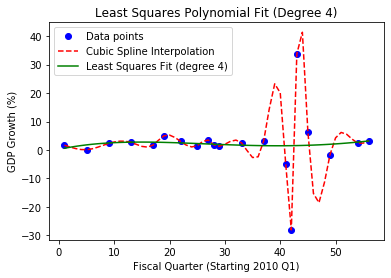

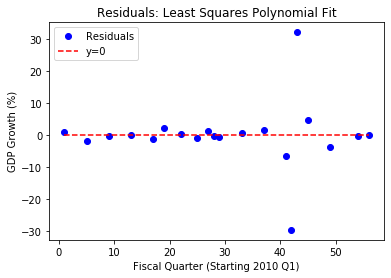

Matrix Condition Number: 18197798.18154116
Root Mean Squared Error: 10.031440678677116

Least Squares Linear Fit (no COVID values):


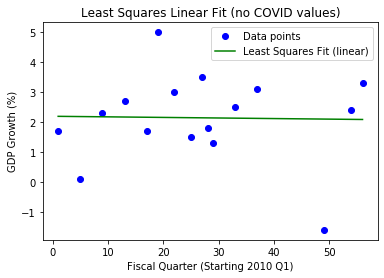

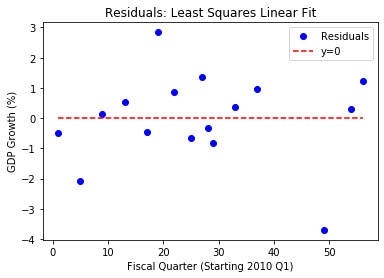

Matrix Condition Number: 60.046553201602904
Root Mean Squared Error: 1.4431864883291987
Slope of linear fit: -0.001906988188976378


In [3]:
"""Part B -- Polynomial and Least Squares Comparison

This cell contains functions to fit either a linear model or an
nth-degree polynomial to a dataset using least squares. Both algorithms
are derived from normal equations to minimize the squared residuals.
A Vandermonde matrix is used for polynomial fitting.

When this cell is run, it will calculate and plot 2 least squares fits
of the Dataset: a degree-4 polynomial fit to the entire Dataset and
plotted alongside the cubic spline interpolation from Part A, and a
linear fit that excludes the COVID quarters (2020 Q1 to 2021 Q1) in the
Dataset. Both plots are accompanied by the corresponding residual plot,
condition number of the Vandermonde matrix, and Root Mean Squared Error
value. The slope of the linear fit is also output.

See below for discussion.

This cell must be run AFTER both the Initialization Block AND Part A in
the kernel.
"""


def create_vandermonde_matrix(x, degree):
    """Create a Vandermonde matrix from a vector going up to a given degree."""
    return np.column_stack([x**d for d in range(degree+1)])


def lstsq_polyfit(x, y, degree):
    """Fit a polynomial of a given degree to a sequence of values using least squares."""
    # Step 1: Create and solve Vandermonde matrix for coefficients of fit
    v = create_vandermonde_matrix(x, degree)
    vt_v = np.dot(v.T, v)
    vt_y = np.dot(v.T, y)
    a = np.linalg.solve(vt_v, vt_y)
    
    # Step 2: Calculate Y values of fit (and interpolate)
    x2 = np.arange(x[0], x[-1]+0.5, dtype=float)
    y2 = sum(a[i]*(x2**i) for i in range(len(a)))
    y2_nosmooth = sum(a[i]*(x**i) for i in range(len(a)))
    return x2, y2, y2_nosmooth, a, v


def lstsq_linfit(x, y):
    """Fit a linear model to a sequence of values using least squares."""
    # Step 1: Solve for the slope m and constant c of the line using the normal equations to minimize error
    n = len(x)
    sx = np.sum(x)
    sy = np.sum(y)
    sx2 = np.sum(x**2)
    sxy = np.sum(x*y)
    m = (n * sxy - sx * sy) / (n * sx2 - sx**2)
    c = (sy - m * sx) / n

    # Values for reporting
    a = np.array([c, m], dtype=float)
    v = np.vstack([x, np.ones(len(x))]).T

    # Step 2: Calculate Y values of fit (and interpolate)
    x2 = np.arange(x[0], x[-1]+0.5, dtype=float)
    y2 = c+m*x2
    y2_nosmooth = c+m*x
    return x2, y2, y2_nosmooth, a, v


# Compute fits
lstsq_fit_deg4 = lstsq_polyfit(x, y, 4)
lstsq_fit_lin = lstsq_linfit(x_nocovid, y_nocovid)

# Plot the polynomial results
print("Least Squares Degree 4 Polynomial Fit:")
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_cs_interp, y_cs_interp, 'r--', label="Cubic Spline Interpolation")
plt.plot(lstsq_fit_deg4[0], lstsq_fit_deg4[1], 'g-', label="Least Squares Fit (degree 4)")
show_plot("Least Squares Polynomial Fit (Degree 4)")
plot_residuals("Least Squares Polynomial Fit", x, y, lstsq_fit_deg4[2])
report_fit_stats(y, lstsq_fit_deg4[2], lstsq_fit_deg4[4])

# Plot the linear results
print("\nLeast Squares Linear Fit (no COVID values):")
plt.plot(x_nocovid, y_nocovid, 'bo', label="Data points")
plt.plot(lstsq_fit_lin[0], lstsq_fit_lin[1], 'g-', label="Least Squares Fit (linear)")
show_plot("Least Squares Linear Fit (no COVID values)")
plot_residuals("Least Squares Linear Fit", x_nocovid, y_nocovid, lstsq_fit_lin[2])
report_fit_stats(y_nocovid, lstsq_fit_lin[2], lstsq_fit_lin[4])
print("Slope of linear fit:", lstsq_fit_lin[3][1])


My implementation of least squares fitting has a time-complexity of O(n). This is the same as the cubic spline interpolation algorithm.

In the first set of data output by the code cell above, there is a least squares degree-4 polynomial fit plotted alongside the cubic spline interpolation from Part A. The polynomial fit is a method of approximation whereas the cubic spline is a method of interpolation. Visually, the polynomial appears to follow the trend in the data better, as it follows the data points without becoming numerically unstable around the outliers like the spline. The plot of the polynomial's residuals shows that it does not deviate too far from most of the original data points, except at the extreme values. Both models are smooth, but the spline is less stable, which makes it harder to interpret at some points. Also, the polynomial can be used to extrapolate beyond the domain of the original dataset, which the spline cannot do.

Despite this, the spline is much more accurate at reproducing specific data points than the polynomial. The smoothness condition guarantees that the spline passes through every data point in the original dataset exactly. The polynomial has no such guarantee, and in fact this particular polynomial fit has a Root Mean Squared Error value of about 10.03, which suggests that it deviates somewhat from the actual values. Also, the Vandermonde matrix used to compute the polynomial fit has a high condition number (18197798), which suggests that it is very sensitive to small changes in the dataset, likely due to the extreme data points.

Overall, approximation (e.g. polynomial fitting) tends to be better for capturing trends in data and extrapolating compared to interpolation (e.g. cubic spline interpolation), which better reproduces the provided data points at the cost of high sensitivity to outliers and generally only being useful for computing values between known data points (interpolation rather than extrapolation).

The second set of data output by the code cell above shows a least squares linear fit of the dataset, excluding values from quarters affected by the COVID pandemic (2020 Q1 to 2021 Q1). This eliminates most of the extreme "outlier" values that negatively affected the stability of previous models. Consequently, this linear fit has a slope of approximately -0.001907 GDP growth % per quarter. This slope is very small and nearly insignificant. Additionally, this linear fit has a relatively high Root Mean Squared Error of 1.443, the residuals are all over the plot, and the matrix used to compute it has a somewhat high condition number of 60.05. Fundamentally, a linear fit assumes that the data will always trend at the same rate for all time. The RMSE and condition number of this fit are much smaller than the polynomial fit computed with the full dataset, which suggests that the COVID exclusion does make the data more stable, but regardless, a linear trend may not make sense for this data, as it fails to pick up on precise trends in the data and the slope suggests that over time, GDP growth hardly changes, which is not true.

# Part C

For a policymaker who needs to estimate GDP growth between two known data points, I would recommend cubic spline interpolation rather than polynomial fitting. A polynomial fit may be more suitable for estimating overall trends in the economy, but for a specific quarter between two known data points, economic data has too much sudden variance for a polynomial to give accurate results. The plots in Part B show relatively high RMSE, which suggests that the polynomial fit is not accurate to the exact values in the dataset, whether or not it captures the trends. Cubic spline interpolation guarantees that the model will pass through all known points. However, care must be taken around extreme outliers, as these may produce unreliable interpolation within nearby intervals. Compared to cubic spline interpolation, a polynomial fit is less likely to be noticably affected by outliers, but therefore in such a case will not interpolate between them at all, which is also undesirable. For interpolating between known values, a cubic spline will be more accurate than a linear fit, and care must be taken to handle outliers in any case.

# Conclusion

Overall, the cubic spline interpolation, polynomial fitting, and least squares linear regression methods are most effective for different purposes. Cubic spline interpolation is an accurate way to interpolate between known points while guaranteeing smoothness and passing through known points in the dataset, but it becomes unstable around outliers and cannot be used to extrapolate new data beyond known points. Polynomial fitting is more effective at capturing overall trends in data compared to cubic spline interpolation as it is smoother overall and less vulnerable to numerical instability caused by outliers, but it is not as accurate for precise values within the dataset compared to cubic spline and therefore is more suitable for trend analysis than interpolation. Least squares linear regression, similarly to polynomial fitting, is smoother and more resistant to outliers than cubic spline interpolation, but does not capture precise trends in data, and so is best for analyzing broad trends or linear relationships compared to a more precise method like polynomial fitting or spline interpolation.